Set up Pyspark

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns 
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder\
    .appName("EDA")\
    .getOrCreate()

## Load data, silver processing 

In [1]:
#Load data

### Clickstream feature

In [9]:
clickstream = spark.read.csv("data/feature_clickstream.csv", header = True, inferSchema = True)
clickstream.printSchema()

root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



In [10]:
clickstream.show(5)

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|  63| 118|  80| 121|  55| 193| 111| 112|-101|   83|  164|  105|  -16|  -81| -126|  114|   35|   85|  -73|   76| CUS_0x1037|   2023-01-01|
|-108| 182| 123|   4| -56|  27|  25|  -6| 284|  222|  203|  190|  -14|  -96|  200|   35|  130|   94|  111|   75| CUS_0x1069|   2023-01-01|
| -13|   8|  87| 166| 214| -98| 215| 152| 129|  139|   14|  203|   26|   86|  171|  125| -130|  354|   17|  302| CUS_0x114a|   2023-01-01|
| -85|  45| 200|  89| 128|  54|  76|  51|  61|  139|    6|  197|  172|   96|  174|  163|   37|  207|  180|  118| CUS_0x1184|   2023-01-01|
|  55| 120| 226| -86| 253| 

In [11]:
clickstream.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------+
|summary|              fe_1|              fe_2|              fe_3|              fe_4|              fe_5|              fe_6|              fe_7|              fe_8|              fe_9|             fe_10|             fe_11|             fe_12|             fe_13|             fe_14|             fe_15|             fe_16|             fe_17|             fe_18|             fe_19|             fe_20|Customer_ID|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+----------------

In [34]:
df_clickstream = spark.read.parquet("datamart/silver/clickstream_clean")
df_clickstream.printSchema()
df_clickstream.show(5)

df_clickstream.toPandas().to_csv("preview_silver_clickstream.csv", index=False)


root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe

### Attributes feature

In [13]:
attributes = spark.read.csv("data/features_attributes.csv", header = True, inferSchema=True)
attributes.printSchema()
attributes.show(5)

root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

+-----------+--------------+---+-----------+-------------+-------------+
|Customer_ID|          Name|Age|        SSN|   Occupation|snapshot_date|
+-----------+--------------+---+-----------+-------------+-------------+
| CUS_0x1000|Alistair Barrf| 18|913-74-1218|       Lawyer|   2023-05-01|
| CUS_0x1009|        Arunah| 26|063-67-6938|     Mechanic|   2025-01-01|
| CUS_0x100b|      Shirboni| 19|  #F%$D@*&8|Media_Manager|   2024-03-01|
| CUS_0x1011|     Schneyerh| 44|793-05-8223|       Doctor|   2023-11-01|
| CUS_0x1013|      Cameront| 44|930-49-9615|     Mechanic|   2023-12-01|
+-----------+--------------+---+-----------+-------------+-------------+
only showing top 5 rows



In [33]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when

spark = SparkSession.builder.getOrCreate()

# Load cleaned attributes data
df_attributes = spark.read.parquet("datamart/silver/attributes_clean")

# Check schema
df_attributes.printSchema()

# Show sample rows
df_attributes.show(5, truncate=False)

# Count nulls per column
df_attributes.select([count(when(col(c).isNull(), c)).alias(c) for c in df_attributes.columns]).show()

# Check unique values in Occupation
df_attributes.groupBy("Occupation").count().orderBy("count", ascending=False).show(30, truncate=False)

# Check invalid SSN (should be empty if cleaned properly)
df_attributes.filter(~col("SSN").rlike("^\\d{3}-\\d{2}-\\d{4}$")).select("SSN").distinct().show(30, truncate=False)

# Export preview CSV if needed
df_attributes.limit(1000).toPandas().to_csv("preview_silver_attributes.csv", index=False)


root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

+-----------+--------------+---+-----------+-------------+-------------+
|Customer_ID|Name          |Age|SSN        |Occupation   |snapshot_date|
+-----------+--------------+---+-----------+-------------+-------------+
|CUS_0x1000 |Alistair Barrf|18 |913-74-1218|Lawyer       |2023-05-01   |
|CUS_0x1009 |Arunah        |26 |063-67-6938|Mechanic     |2025-01-01   |
|CUS_0x100b |Shirboni      |19 |NULL       |Media_Manager|2024-03-01   |
|CUS_0x1011 |Schneyerh     |44 |793-05-8223|Doctor       |2023-11-01   |
|CUS_0x1013 |Cameront      |44 |930-49-9615|Mechanic     |2023-12-01   |
+-----------+--------------+---+-----------+-------------+-------------+
only showing top 5 rows

+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN

### Financials feature 

In [7]:
financials = spark.read.csv("data/features_financials.csv", header = True, inferSchema = True)
financials.printSchema()
financials.show(5)

root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: string (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: string (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: string (nullable = true)
 |-- Changed_Credit_Limit: string (nullable = true)
 |-- Num_Credit_Inquiries: double (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: string (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: string (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- Mont

Plotting Annual income

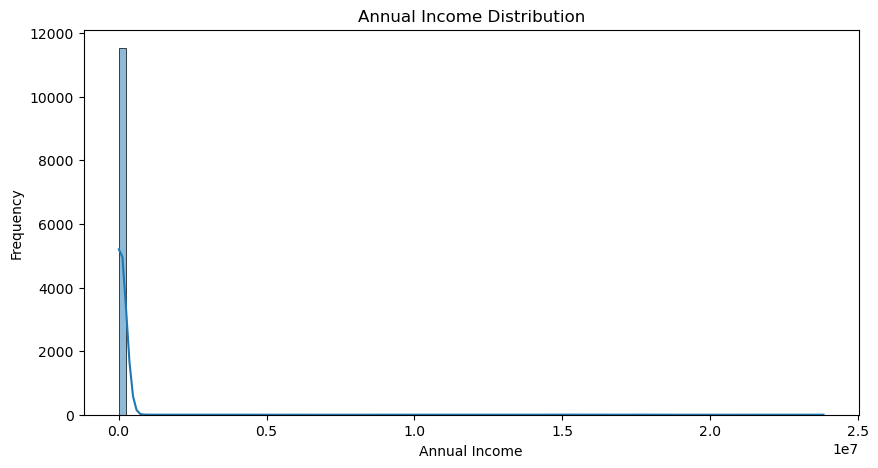

In [13]:
financials = financials.replace(["_", "NA"], None) 
financials_cast = financials.withColumn("Annual_Income", col("Annual_Income").cast("double"))

pdf = financials_cast.select("Annual_Income").dropna().toPandas()
# Plot
plt.figure(figsize=(10,5))
sns.histplot(pdf["Annual_Income"], bins=100, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

Annual income seems to be right-skewed, with many small income and some few extremely large income. 

In [15]:
pdf["Annual_Income"].sort_values(ascending=False).head(20)


4791     23834698.0
4112     22409880.0
2066     22225113.0
3875     22136920.0
7056     21964843.0
7714     21762134.0
2595     21752116.0
7739     21001046.0
8526     20501034.0
4122     20441835.0
10008    20368494.0
11422    19768015.0
207      19473209.0
11498    19134169.0
9832     18884777.0
671      18320277.0
9476     17938268.0
6878     17872695.0
4784     17741279.0
356      17706148.0
Name: Annual_Income, dtype: float64

In [16]:
q99 = pdf["Annual_Income"].quantile(0.99)
trimmed = pdf[pdf["Annual_Income"] < q99]
trimmed["Annual_Income"].median()


36886.274999999994

In [18]:
from pyspark.sql.functions import col, count, when

total = financials.count()
missing = financials.filter(col("Annual_Income").isNull()).count()
pct_missing = (missing / total) * 100
print(f"Missing % = {pct_missing:.2f}%")


Missing % = 0.00%


Checking valid payment behaviours

In [20]:
financials.select("Payment_Behaviour").distinct().orderBy("Payment_Behaviour").show(truncate=False)


+--------------------------------+
|Payment_Behaviour               |
+--------------------------------+
|!@9#%8                          |
|High_spent_Large_value_payments |
|High_spent_Medium_value_payments|
|High_spent_Small_value_payments |
|Low_spent_Large_value_payments  |
|Low_spent_Medium_value_payments |
|Low_spent_Small_value_payments  |
+--------------------------------+



In [21]:
financials.select("Credit_History_Age").distinct().orderBy("Payment_Behaviour").show(truncate=False)


+----------------------+
|Credit_History_Age    |
+----------------------+
|17 Years and 8 Months |
|32 Years and 8 Months |
|17 Years and 9 Months |
|12 Years and 8 Months |
|2 Years and 10 Months |
|16 Years and 0 Months |
|2 Years and 3 Months  |
|25 Years and 4 Months |
|27 Years and 11 Months|
|1 Years and 2 Months  |
|27 Years and 6 Months |
|16 Years and 3 Months |
|28 Years and 1 Months |
|21 Years and 8 Months |
|3 Years and 5 Months  |
|23 Years and 1 Months |
|30 Years and 0 Months |
|24 Years and 5 Months |
|30 Years and 10 Months|
|17 Years and 7 Months |
+----------------------+
only showing top 20 rows



In [22]:
financials.select("Type_of_Loan").distinct().orderBy("Payment_Behaviour").show(truncate=False)


+---------------------------------------------------------------------------------------------------------------------------------------+
|Type_of_Loan                                                                                                                           |
+---------------------------------------------------------------------------------------------------------------------------------------+
|Auto Loan, Debt Consolidation Loan, Not Specified, Credit-Builder Loan, Personal Loan, Home Equity Loan, Payday Loan, and Not Specified|
|Auto Loan, Not Specified, Personal Loan, Personal Loan, and Auto Loan                                                                  |
|Auto Loan, Debt Consolidation Loan, Student Loan, Personal Loan, Home Equity Loan, and Student Loan                                    |
|Auto Loan, Debt Consolidation Loan, Mortgage Loan, and Not Specified                                                                   |
|Auto Loan, Debt Consolidation Loa

##### Test financials_clean

In [22]:
df_financials = spark.read.parquet("datamart/silver/financials_clean")
df_financials.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: double (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: double (nullable = true)
 |-- Num_Credit_Inquiries: integer (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: double (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: double (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- M

In [23]:
df_financials.select("Payment_Behaviour").distinct().orderBy("Payment_Behaviour").show(1000, truncate=False)


+--------------------------------+
|Payment_Behaviour               |
+--------------------------------+
|NULL                            |
|High_spent_Large_value_payments |
|High_spent_Medium_value_payments|
|High_spent_Small_value_payments |
|Low_spent_Large_value_payments  |
|Low_spent_Medium_value_payments |
|Low_spent_Small_value_payments  |
+--------------------------------+



In [24]:
df_financials.select("Num_of_Loan").distinct().orderBy("Payment_Behaviour").show(1000, truncate=False)


+-----------+
|Num_of_Loan|
+-----------+
|4          |
|6          |
|7          |
|18         |
|65         |
|1085       |
|1159       |
|1412       |
|237        |
|455        |
|614        |
|795        |
|945        |
|999        |
|1053       |
|1480       |
|1          |
|2          |
|3          |
|5          |
|365        |
|387        |
|404        |
|1127       |
|1384       |
|1393       |
|83         |
|119        |
|192        |
|251        |
|781        |
|860        |
|1070       |
|1137       |
|1257       |
|8          |
|55         |
|58         |
|146        |
|227        |
|438        |
|699        |
|917        |
|1478       |
|1495       |
|27         |
|33         |
|103        |
|497        |
|520        |
|653        |
|1091       |
|0          |
|9          |
|31         |
|87         |
|100        |
|172        |
|186        |
|285        |
|332        |
|420        |
|439        |
|463        |
|777        |
|785        |
|799        |
|966        |
|1014 

In [25]:
df_financials.select("Num_of_Loan").distinct().orderBy("Payment_Behaviour").show(1000, truncate=False)


+-----------+
|Num_of_Loan|
+-----------+
|4          |
|6          |
|7          |
|18         |
|65         |
|1085       |
|1159       |
|1412       |
|237        |
|455        |
|614        |
|795        |
|945        |
|999        |
|1053       |
|1480       |
|1          |
|2          |
|3          |
|5          |
|365        |
|387        |
|404        |
|1127       |
|1384       |
|1393       |
|83         |
|119        |
|192        |
|251        |
|781        |
|860        |
|1070       |
|1137       |
|1257       |
|8          |
|55         |
|58         |
|146        |
|227        |
|438        |
|699        |
|917        |
|1478       |
|1495       |
|27         |
|33         |
|103        |
|497        |
|520        |
|653        |
|1091       |
|0          |
|9          |
|31         |
|87         |
|100        |
|172        |
|186        |
|285        |
|332        |
|420        |
|439        |
|463        |
|777        |
|785        |
|799        |
|966        |
|1014 

In [30]:
df.toPandas().to_csv("preview_silver_financials.csv", index=False)


### Loan 

In [19]:
loans = spark.read.csv("data/lms_loan_daily.csv", header=True, inferSchema=True)
loans.printSchema()
loans.show(5)


root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: integer (nullable = true)
 |-- due_amt: double (nullable = true)
 |-- paid_amt: double (nullable = true)
 |-- overdue_amt: double (nullable = true)
 |-- balance: double (nullable = true)
 |-- snapshot_date: date (nullable = true)

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|              0|   10000|    0.0|     0.0|        0.0|10000.0|   2023-05-01|

In [35]:
df_loans = spark.read.parquet("datamart/silver/loans_clean")
df_loans.select("Customer_ID", "loan_id", "dpd", "mob", "installments_missed").show(5)
df_loans.toPandas().to_csv("loans_clean_sample.csv", index=False)


+-----------+--------------------+---+---+-------------------+
|Customer_ID|             loan_id|dpd|mob|installments_missed|
+-----------+--------------------+---+---+-------------------+
| CUS_0x5012|CUS_0x5012_2023_1...|184| 10|                  6|
| CUS_0x501c|CUS_0x501c_2024_0...| 92|  6|                  3|
| CUS_0x501d|CUS_0x501d_2024_0...|  0|  7|                  0|
| CUS_0x5035|CUS_0x5035_2023_1...|  0|  9|                  0|
| CUS_0x5044|CUS_0x5044_2024_0...|  0|  8|                  0|
+-----------+--------------------+---+---+-------------------+
only showing top 5 rows



# EDA for gold feature processing 

## Financial features

In [26]:
from pyspark.sql.functions import col, add_months

# Load snapshot dates
financials = spark.read.parquet("datamart/silver/financials_clean").select("snapshot_date").distinct()
clickstream = spark.read.parquet("datamart/silver/clickstream_clean").select("snapshot_date").distinct()
attributes = spark.read.parquet("datamart/silver/attributes_clean").select("snapshot_date").distinct()
loans = spark.read.parquet("datamart/silver/loans_clean").select("snapshot_date").distinct().withColumnRenamed("snapshot_date", "loans_snapshot_date")

# Intersect common snapshot dates among all feature sources
common_dates = financials.intersect(clickstream).intersect(attributes)

# Check which of these have label data available at +6 months
candidate_dates = common_dates.withColumn("label_cutoff", add_months(col("snapshot_date"), 6))
joined = candidate_dates.join(loans, loans["loans_snapshot_date"] >= candidate_dates["label_cutoff"], how="inner")

# Find latest valid snapshot_date for feature building
latest_valid_date = joined.select("snapshot_date").distinct().orderBy(col("snapshot_date").desc()).limit(1).collect()[0]["snapshot_date"]

print("📌 Chosen snapshot_date to build features:", latest_valid_date)


📌 Chosen snapshot_date to build features: 2024-12-01


In [28]:
from pyspark.sql.functions import min, max

def print_snapshot_date_ranges(spark):
    paths = {
        "financials": "datamart/silver/financials_clean",
        "clickstream": "datamart/silver/clickstream_clean",
        "attributes": "datamart/silver/attributes_clean",
        "loans": "datamart/silver/loans_clean"
    }

    for name, path in paths.items():
        df = spark.read.parquet(path)
        min_max = df.select(min("snapshot_date").alias("min_date"), max("snapshot_date").alias("max_date")).collect()[0]
        print(f"📅 {name.capitalize()} date range: {min_max['min_date']} → {min_max['max_date']}")

print_snapshot_date_ranges(spark)


📅 Financials date range: 2023-01-01 → 2025-01-01
📅 Clickstream date range: 2023-01-01 → 2024-12-01
📅 Attributes date range: 2023-01-01 → 2025-01-01
📅 Loans date range: 2023-01-01 → 2025-11-01


In [30]:
from pyspark.sql.functions import col

loans = spark.read.parquet("datamart/silver/loans_clean")
financials = spark.read.parquet("datamart/silver/financials_clean")
clickstream = spark.read.parquet("datamart/silver/clickstream_clean")
attributes = spark.read.parquet("datamart/silver/attributes_clean")

loans_dates = loans.select("snapshot_date").distinct()
financials_dates = financials.select("snapshot_date").distinct()
clickstream_dates = clickstream.select("snapshot_date").distinct()
attributes_dates = attributes.select("snapshot_date").distinct()


In [31]:
common_snapshots = loans_dates \
    .intersect(financials_dates) \
    .intersect(clickstream_dates) \
    .intersect(attributes_dates)


In [33]:
from pyspark.sql.functions import col
import pandas as pd
import pyspark.sql.functions as F


valid_snapshots = [row.snapshot_date for row in common_snapshots.collect()]
dpd_cutoff = 30
mob_cutoff = 6

loans = spark.read.parquet("datamart/silver/loans_clean")

results = []
for snap in valid_snapshots:
    cutoff = pd.to_datetime(snap) + pd.DateOffset(months=mob_cutoff)
    filtered = loans.filter(
        (col("snapshot_date") == snap) &
        (col("mob") == mob_cutoff)
    ).withColumn("label", F.when(col("dpd") >= dpd_cutoff, 1).otherwise(0))

    count_total = filtered.count()
    count_label_1 = filtered.filter(col("label") == 1).count()
    results.append((snap.strftime("%Y-%m-%d"), count_total, count_label_1))

# Show result as DataFrame
df_counts = pd.DataFrame(results, columns=["snapshot_date", "total", "label_1"])
df_counts["pct_label_1"] = (df_counts["label_1"] / df_counts["total"]).round(3)
df_counts.sort_values("snapshot_date", ascending=True)


,snapshot_date,total,label_1,pct_label_1
23,2023-01-01,0,0,NaN
22,2023-02-01,0,0,NaN
21,2023-03-01,0,0,NaN
20,2023-04-01,0,0,NaN
19,2023-05-01,0,0,NaN
18,2023-06-01,0,0,NaN
17,2023-07-01,530,140,0.264
16,2023-08-01,501,154,0.307
15,2023-09-01,506,162,0.320
14,2023-10-01,510,137,0.269


### Merging financial features with loans 

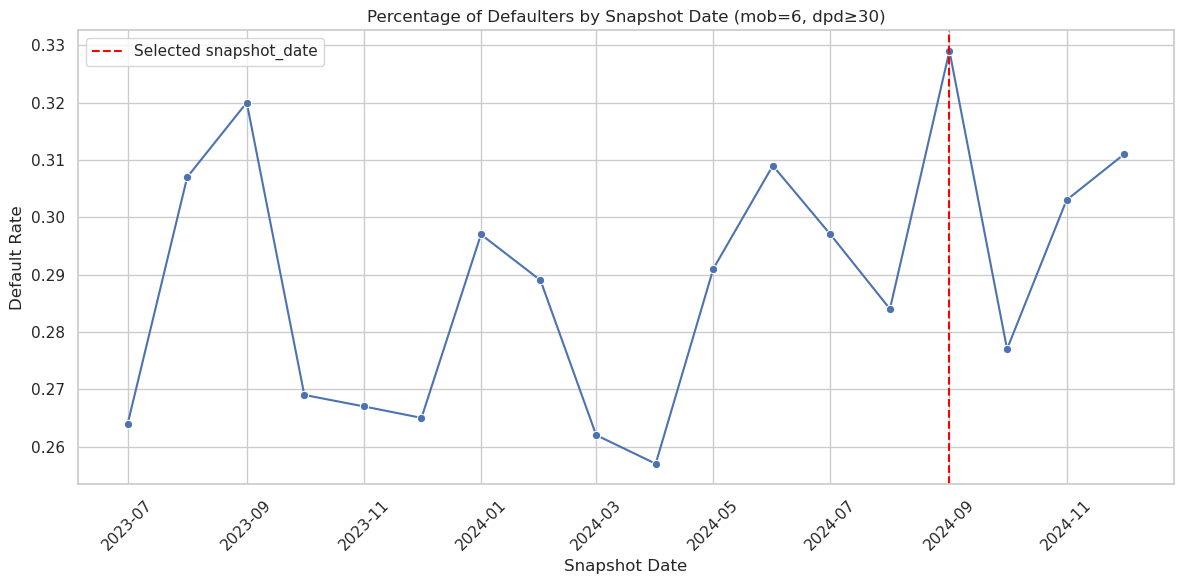

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure snapshot_date is datetime
df_counts["snapshot_date"] = pd.to_datetime(df_counts["snapshot_date"])

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_counts, x="snapshot_date", y="pct_label_1", marker="o")
plt.axvline(pd.to_datetime("2024-09-01"), color="red", linestyle="--", label="Selected snapshot_date")
plt.title("Percentage of Defaulters by Snapshot Date (mob=6, dpd≥30)")
plt.xlabel("Snapshot Date")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("eda_defaulter_rate_by_snapshot_date.png", dpi=300, bbox_inches='tight')
plt.show()

In [39]:
from pyspark.sql.functions import col, lit, when
import pandas as pd

# Load data
financials = spark.read.parquet("datamart/silver/financials_clean")
loans = spark.read.parquet("datamart/silver/loans_clean")

dpd_cutoff = 30
mob_cutoff = 6

# Get valid snapshot dates
financial_dates = financials.select("snapshot_date").distinct().toPandas()
loan_dates = loans.select("snapshot_date").distinct().toPandas()

# Convert to datetime
financial_dates["snapshot_date"] = pd.to_datetime(financial_dates["snapshot_date"])
loan_dates["snapshot_date"] = pd.to_datetime(loan_dates["snapshot_date"])

# Pair dates
valid_pairs = []
for d in sorted(financial_dates["snapshot_date"]):
    label_date = d + pd.DateOffset(months=mob_cutoff)
    if label_date in list(loan_dates["snapshot_date"]):
        valid_pairs.append((d, label_date))

# Build the training set
training_rows = []
for snapshot_date, label_date in valid_pairs:
    # Features from snapshot_date
    f_snap = financials.filter(col("snapshot_date") == lit(snapshot_date))
    
    # Labels from label_date
    l_snap = loans.filter(
        (col("snapshot_date") == lit(label_date)) &
        (col("mob") == mob_cutoff)
    ).withColumn("label", when(col("dpd") >= dpd_cutoff, 1).otherwise(0)) \
     .select("Customer_ID", "label")

    # Join
    joined = f_snap.join(l_snap, on="Customer_ID", how="inner") \
                   .withColumn("feature_snapshot_date", lit(snapshot_date)) \
                   .withColumn("label_snapshot_date", lit(label_date))
    
    training_rows.append(joined)

# Combine all
if training_rows:
    training_df = training_rows[0]
    for df in training_rows[1:]:
        training_df = training_df.unionByName(df)

    training_df.cache()
    print(f"✅ Final multi-snapshot training set: {training_df.count()} rows")
    training_df.limit(5).toPandas()  # Preview
else:
    print("❌ No valid training data found.")


✅ Final multi-snapshot training set: 12500 rows


In [41]:
training_df.limit(5).toPandas()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date,Loan_Types_Array,label,feature_snapshot_date,label_snapshot_date
0,CUS_0x1037,15989.085,1086.423750,5,4,2,4,"Credit-Builder Loan, Auto Loan, Auto Loan, and...",13,15,...,No,33.797021,80.465240,Low_spent_Small_value_payments,284.380115,2023-01-01,"[credit-builder loan, auto loan, auto loan, an...",0,2023-01-01,2023-07-01
1,CUS_0x1069,58637.340,4799.445000,4,6,10,119,"Personal Loan, Auto Loan, and Not Specified",9,17,...,Yes,139.885013,165.210613,High_spent_Small_value_payments,434.848874,2023-01-01,"[personal loan, auto loan, and not specified]",0,2023-01-01,2023-07-01
2,CUS_0x114a,15305.460,1230.455000,0,7,2,2,"Student Loan, and Home Equity Loan",14,2,...,No,20.301654,64.778480,Low_spent_Small_value_payments,327.965366,2023-01-01,"[student loan, and home equity loan]",0,2023-01-01,2023-07-01
3,CUS_0x1184,19867.475,1396.622917,3,5,11,3,"Student Loan, Mortgage Loan, and Payday Loan",10,9,...,No,42.606882,23.460944,None,313.594466,2023-01-01,"[student loan, mortgage loan, and payday loan]",0,2023-01-01,2023-07-01
4,CUS_0x1297,57738.060,4881.505000,9,8,30,9,"Payday Loan, Personal Loan, Payday Loan, Perso...",61,24,...,Yes,296.284136,53.821178,High_spent_Medium_value_payments,388.045187,2023-01-01,"[payday loan, personal loan, payday loan, pers...",1,2023-01-01,2023-07-01


In [52]:
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import builtins                     


sns.set(style="whitegrid")

NUMERIC_COLS = [
    "Annual_Income", "Monthly_Inhand_Salary", "Outstanding_Debt",
    "Monthly_Balance", "Amount_invested_monthly", "Changed_Credit_Limit",
    "Total_EMI_per_month", "Credit_Utilization_Ratio",
    "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
    "Num_of_Loan", "Num_of_Delayed_Payment", "Num_Credit_Inquiries"
]

CATEGORICAL_COLS = [
    "Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"
]
def sample_spark(df, n=20_000):
    frac = builtins.min(1.0, n / df.count())   # ✅ dùng built-in min
    return df.sample(fraction=frac, seed=42).toPandas()

# 1. Missing-value overview
missing = (
    training_df.select(
        *[
            (F.count(F.when(F.col(c).isNull(), c)) / F.count("*")).alias(c)
            for c in NUMERIC_COLS + CATEGORICAL_COLS
        ]
    )
    .toPandas()
    .T.rename(columns={0: "missing_pct"})
    .sort_values("missing_pct", ascending=False)
)
display(missing.head(15))


,missing_pct
Credit_Mix,0.20888
Payment_Behaviour,0.07984
Changed_Credit_Limit,0.02032
Outstanding_Debt,0.01112
Monthly_Balance,0.00008
Interest_Rate,0.00000
Payment_of_Min_Amount,0.00000
Num_Credit_Inquiries,0.00000
Num_of_Delayed_Payment,0.00000
Num_of_Loan,0.00000


**Checking distribution**

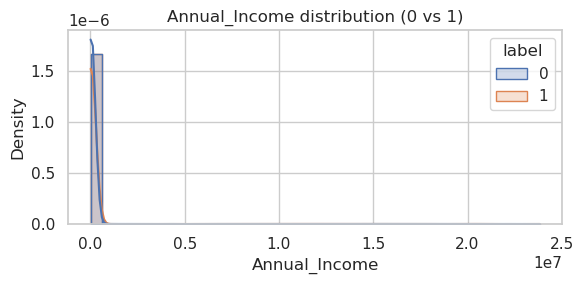

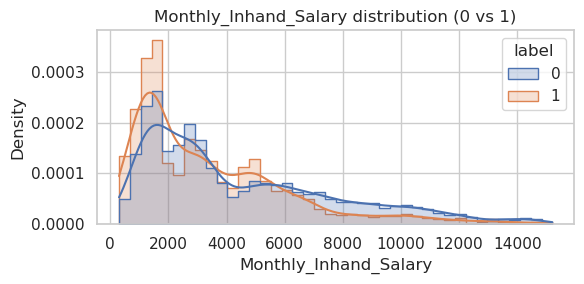

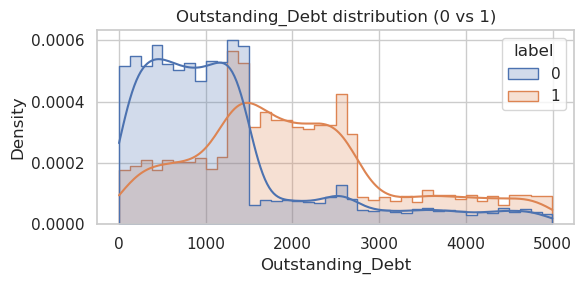

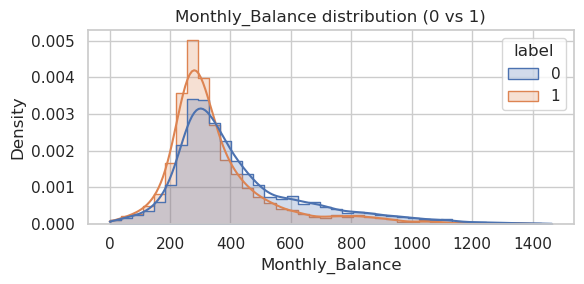

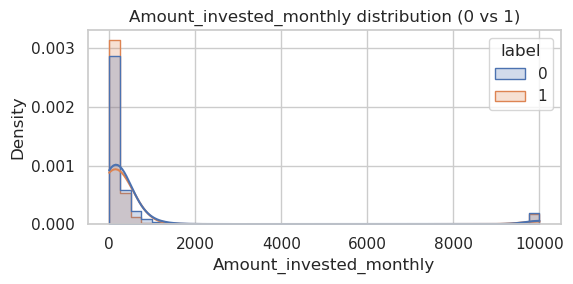

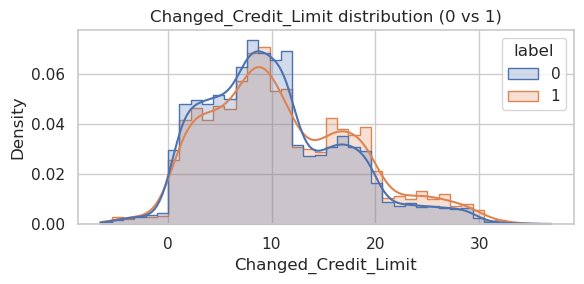

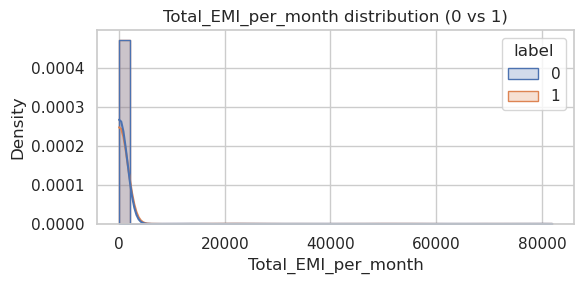

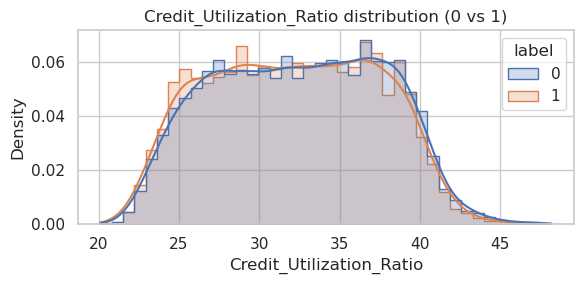

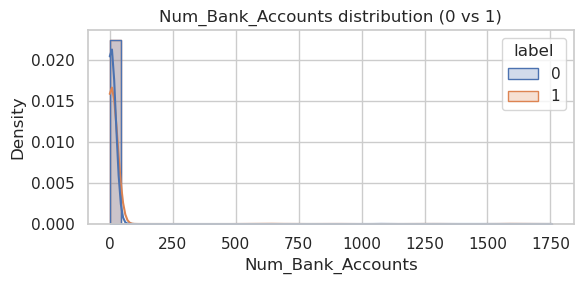

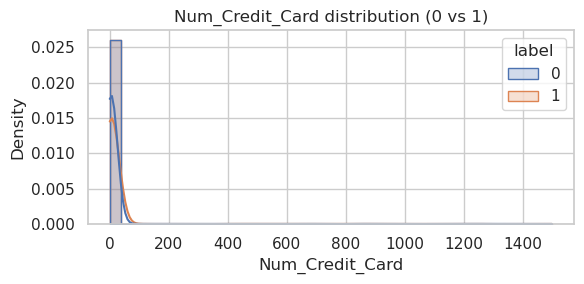

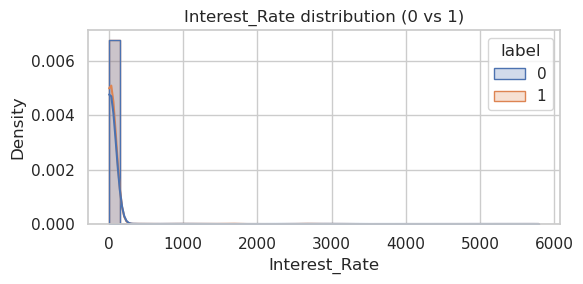

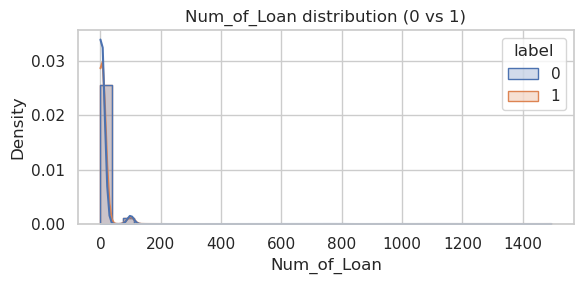

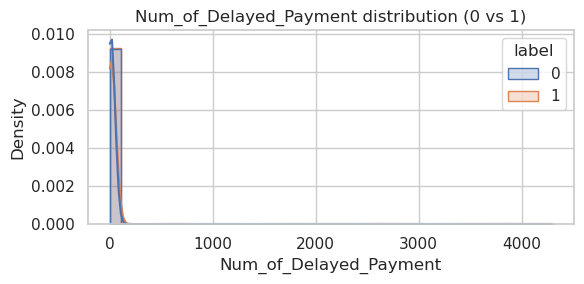

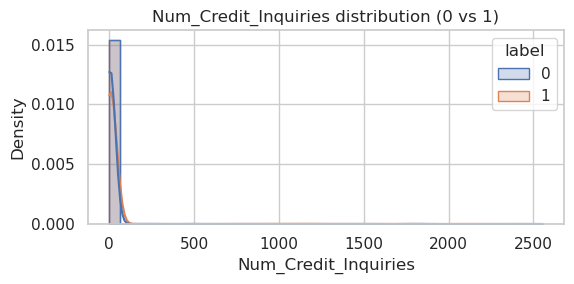

In [53]:
pdf = sample_spark(training_df.select(NUMERIC_COLS + ["label"]))

for colname in NUMERIC_COLS:
    plt.figure(figsize=(6, 3))
    sns.histplot(
        data=pdf, x=colname, hue="label",
        bins=40, kde=True, element="step", stat="density", common_norm=False
    )
    plt.title(f"{colname} distribution (0 vs 1)")
    plt.tight_layout()
    plt.show()

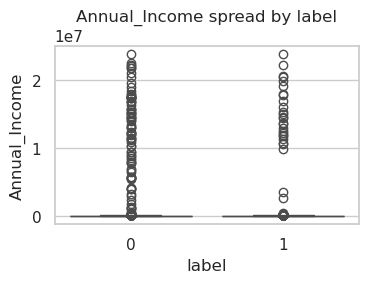

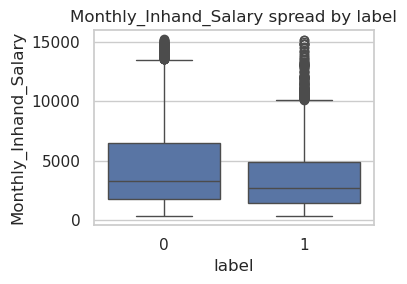

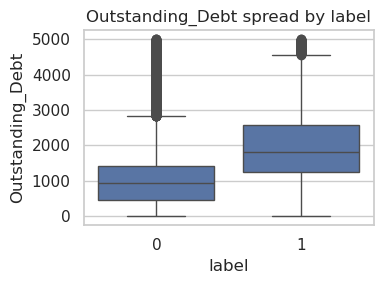

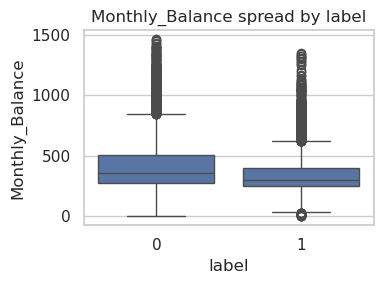

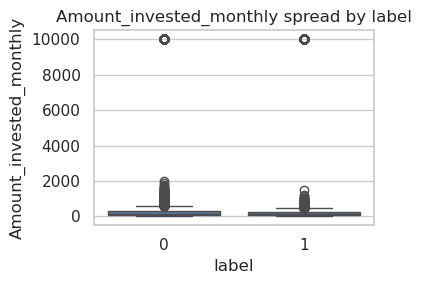

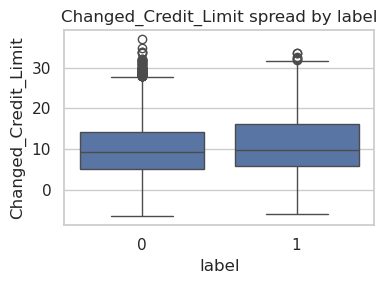

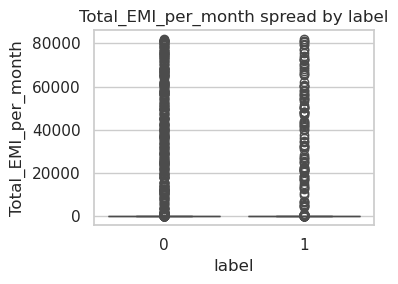

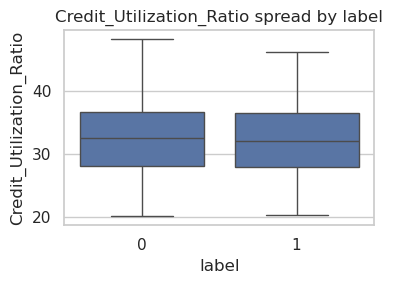

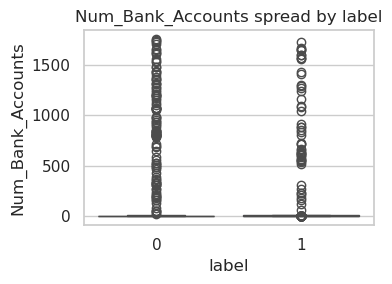

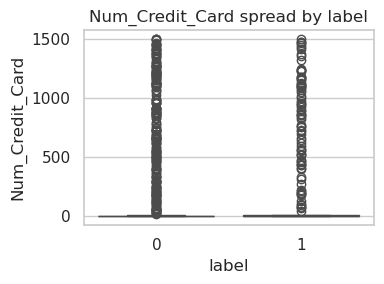

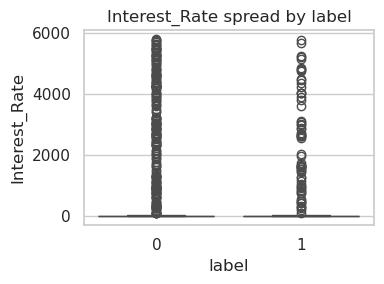

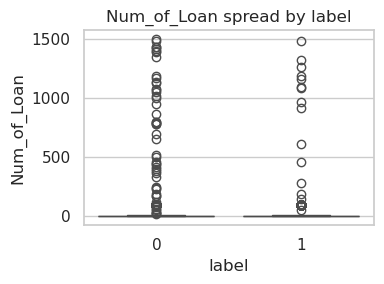

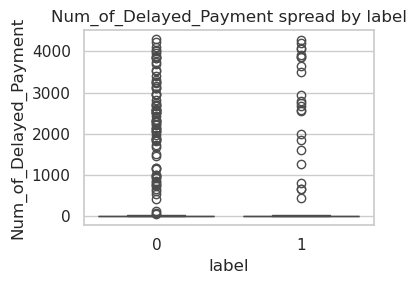

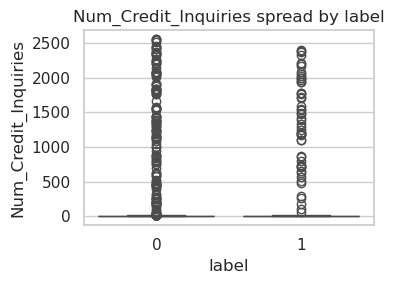

In [54]:
# 3. Box-plots for distribution spread
for colname in NUMERIC_COLS:
    plt.figure(figsize=(4, 3))
    sns.boxplot(data=pdf, x="label", y=colname)
    plt.title(f"{colname} spread by label")
    plt.tight_layout()
    plt.show()

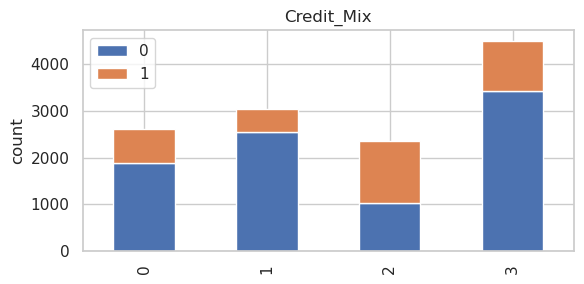

Credit_Mix:  p-value = 6.372e-252


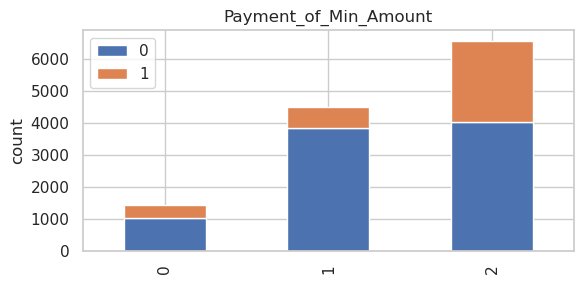

Payment_of_Min_Amount:  p-value = 5.286e-173


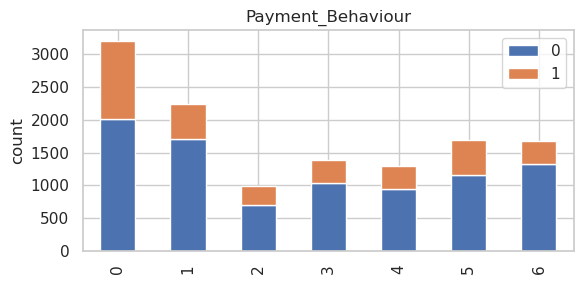

Payment_Behaviour:  p-value = 3.061e-39


In [57]:
# 4. Categorical feature vs label chi-square / bar-plots

from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

for colname in CATEGORICAL_COLS:
    tmp = (
        training_df.groupBy(colname, "label")
        .count()
        .groupBy(colname)
        .pivot("label")
        .sum("count")
        .fillna(0)
    ).toPandas()

    # BAR PLOT 
    tmp.plot(kind="bar", stacked=True, figsize=(6, 3), title=colname)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    # CHI-SQUARE 
    # column names are strings "0", "1" after pivot
    cols_needed = ["0", "1"]
    # if one label is missing, add a zero-filled column so chi2 works
    for c in cols_needed:
        if c not in tmp.columns:
            tmp[c] = 0

    chi2, p, _, _ = chi2_contingency(tmp[cols_needed])
    print(f"{colname}:  p-value = {p:.4g}")


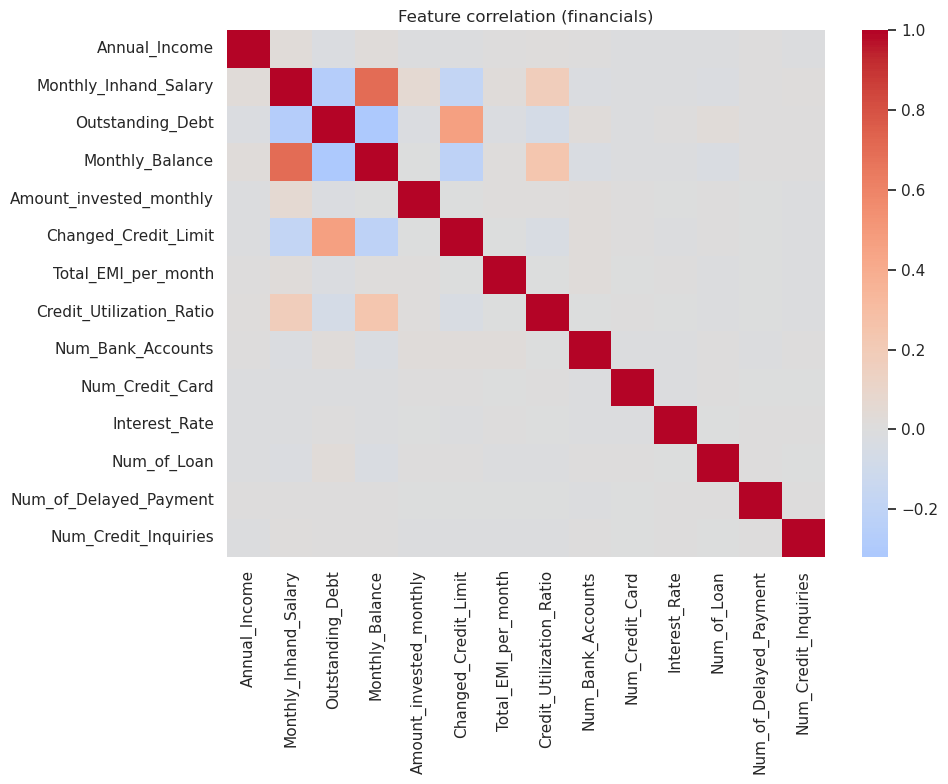

In [56]:
# 5. Correlation heat-map (numeric only)
corr_pdf = (
    training_df.select(NUMERIC_COLS).toPandas().corr()
)
plt.figure(figsize=(10,8))
sns.heatmap(corr_pdf, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation (financials)")
plt.tight_layout()
plt.show()

**Numerical feature transformation**

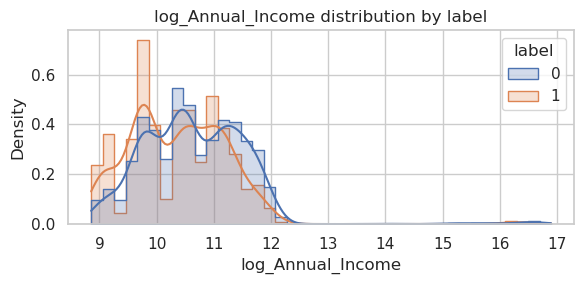

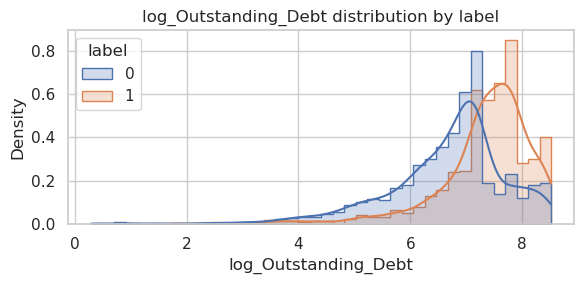

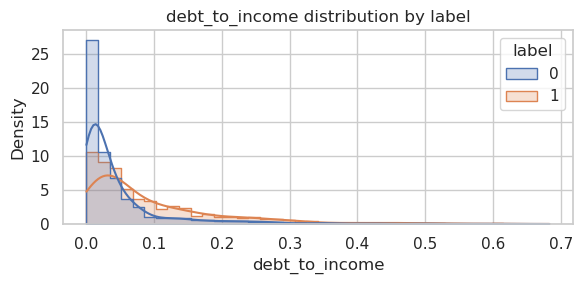

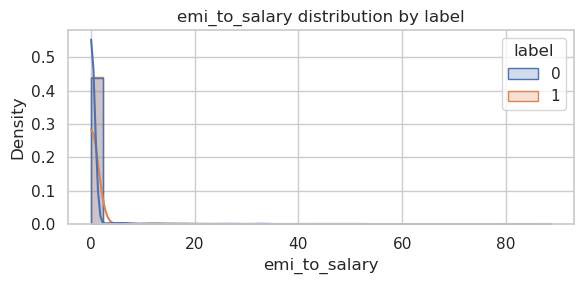

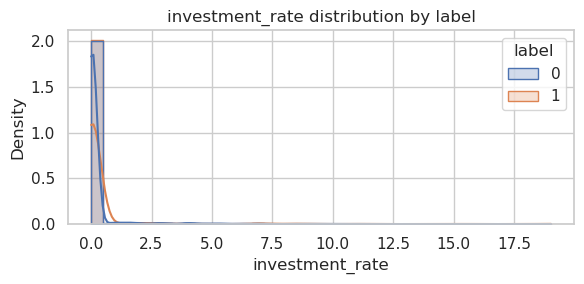

In [61]:
# 1. Drop rows with null Monthly_Balance (0.008%)
import pandas as pd
import numpy as np
import pyspark.sql.functions as F
from pyspark.sql.functions import when, col, log1p
from pyspark.sql.types import DoubleType
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")


training_df = training_df.filter(col("Monthly_Balance").isNotNull())

# 2. Impute missing values
training_df = training_df.fillna({
    "Outstanding_Debt": training_df.approxQuantile("Outstanding_Debt", [0.5], 0.001)[0],
    "Changed_Credit_Limit": 0,
    "Credit_Mix": "Unknown",
    "Payment_Behaviour": "Unknown"
})

# 3. Log transform skewed features
training_df = training_df.withColumn("log_Annual_Income", log1p("Annual_Income"))
training_df = training_df.withColumn("log_Outstanding_Debt", log1p("Outstanding_Debt"))

# ENGINEER NEW FEATURES 
# 4. Create new ratio-based features
training_df = training_df.withColumn(
    "debt_to_income",
    (col("Outstanding_Debt") / col("Annual_Income")).cast(DoubleType())
)

training_df = training_df.withColumn(
    "emi_to_salary",
    (col("Total_EMI_per_month") / col("Monthly_Inhand_Salary")).cast(DoubleType())
)

training_df = training_df.withColumn(
    "investment_rate",
    (col("Amount_invested_monthly") / col("Monthly_Inhand_Salary")).cast(DoubleType())
)

training_df = training_df.withColumn(
    "has_credit_limit_change",
    (col("Changed_Credit_Limit") != 0).cast("int")
)

# 5. Cap outliers on some extreme-value fields
for cap_col, upper in [
    ("Num_Bank_Accounts", 20),
    ("Num_Credit_Card", 20),
    ("Num_Credit_Inquiries", 50),
]:
    training_df = training_df.withColumn(
        cap_col,
        when(col(cap_col) > upper, upper).otherwise(col(cap_col))
    )

# 6. Sample for EDA plotting
final_pdf = training_df.sample(fraction=0.3, seed=42).toPandas()

# 7. Visualize new features
def plot_feature_dist(df, features, hue="label"):
    for feat in features:
        plt.figure(figsize=(6, 3))
        sns.histplot(df, x=feat, hue=hue, bins=40, kde=True, stat="density", element="step", common_norm=False)
        plt.title(f"{feat} distribution by label")
        plt.tight_layout()
        plt.show()

plot_feature_dist(final_pdf, [
    "log_Annual_Income",
    "log_Outstanding_Debt",
    "debt_to_income",
    "emi_to_salary",
    "investment_rate"
])

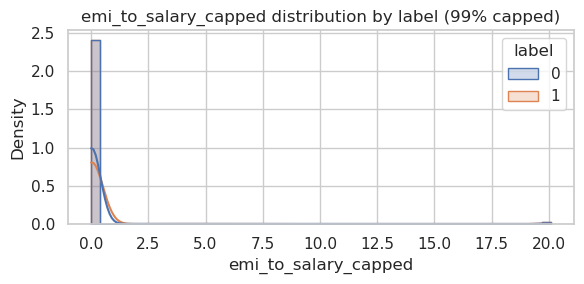

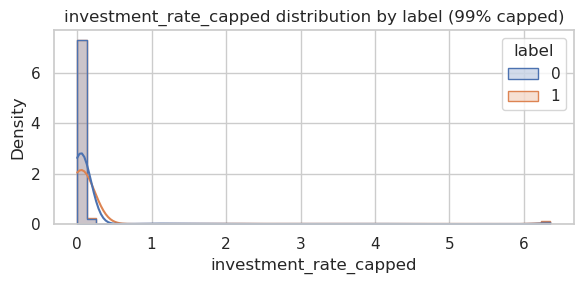

In [62]:
# Cap extreme values at 99th percentile to improve plot visibility
# Derived features
pdf["debt_to_income"] = pdf["Outstanding_Debt"] / (pdf["Annual_Income"] + 1e-3)
pdf["emi_to_salary"] = pdf["Total_EMI_per_month"] / (pdf["Monthly_Inhand_Salary"] + 1e-3)
pdf["investment_rate"] = pdf["Amount_invested_monthly"] / (pdf["Monthly_Inhand_Salary"] + 1e-3)

# Winsorize (cap extreme outliers at 99th percentile)
emi_cap = pdf["emi_to_salary"].quantile(0.99)
inv_cap = pdf["investment_rate"].quantile(0.99)

pdf["emi_to_salary_capped"] = pdf["emi_to_salary"].clip(upper=emi_cap)
pdf["investment_rate_capped"] = pdf["investment_rate"].clip(upper=inv_cap)

for colname in ["emi_to_salary_capped", "investment_rate_capped"]:
    plt.figure(figsize=(6, 3))
    sns.histplot(
        data=pdf, x=colname, hue="label",
        bins=50, kde=True, element="step", stat="density", common_norm=False
    )
    plt.title(f"{colname} distribution by label (99% capped)")
    plt.tight_layout()
    plt.show()


**Categorical feature transformation**

In [63]:
from pyspark.sql.functions import when, col
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# 1. Impute missing values
training_df_imputed = (
    training_df
    .withColumn("Credit_Mix", when(col("Credit_Mix").isNull(), "Unknown").otherwise(col("Credit_Mix")))
    .withColumn("Payment_Behaviour", when(col("Payment_Behaviour").isNull(), "Unknown").otherwise(col("Payment_Behaviour")))
)

# 2. Define categorical columns
CATEGORICAL_COLS = ["Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"]

# 3. Build StringIndexer and OneHotEncoder pipeline
indexers = [StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") for col in CATEGORICAL_COLS]
encoders = [OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_ohe") for col in CATEGORICAL_COLS]

pipeline = Pipeline(stages=indexers + encoders)

# 4. Fit + transform
cat_model = pipeline.fit(training_df_imputed)
training_df_encoded = cat_model.transform(training_df_imputed)

# 5. Keep only useful columns (drop intermediate *_idx if needed)
categorical_feature_cols = [f"{col}_ohe" for col in CATEGORICAL_COLS]


In [65]:
for colname in CATEGORICAL_COLS:
    (
        training_df.groupBy(colname, "label")
        .count()
        .orderBy(colname, "label")
        .show(truncate=False)
    )


+----------+-----+-----+
|Credit_Mix|label|count|
+----------+-----+-----+
|Bad       |0    |1035 |
|Bad       |1    |1325 |
|Good      |0    |2551 |
|Good      |1    |481  |
|Standard  |0    |3426 |
|Standard  |1    |1071 |
|Unknown   |0    |1886 |
|Unknown   |1    |724  |
+----------+-----+-----+

+---------------------+-----+-----+
|Payment_of_Min_Amount|label|count|
+---------------------+-----+-----+
|NM                   |0    |1018 |
|NM                   |1    |420  |
|No                   |0    |3858 |
|No                   |1    |632  |
|Yes                  |0    |4022 |
|Yes                  |1    |2549 |
+---------------------+-----+-----+

+--------------------------------+-----+-----+
|Payment_Behaviour               |label|count|
+--------------------------------+-----+-----+
|High_spent_Large_value_payments |0    |1327 |
|High_spent_Large_value_payments |1    |356  |
|High_spent_Medium_value_payments|0    |1710 |
|High_spent_Medium_value_payments|1    |532  |
|High_spe

Summary DataFrame for Plotting:
  Credit_Mix  Non_Default_Count  Default_Count  Total_Count  Default_Rate
0        Bad               1035           1325         2360      0.561441
3    Unknown               1886            724         2610      0.277395
2   Standard               3426           1071         4497      0.238159
1       Good               2551            481         3032      0.158641


/tmp/ipykernel_733/1539763424.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Credit_Mix', y='Default_Rate', data=summary_df, palette="viridis")


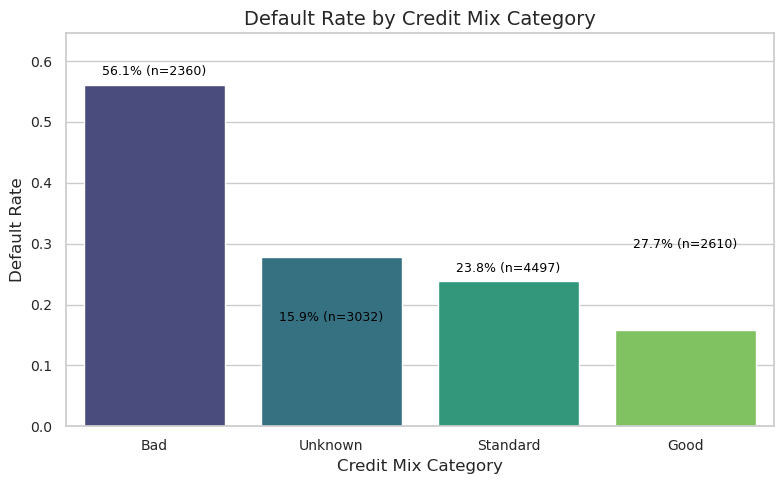

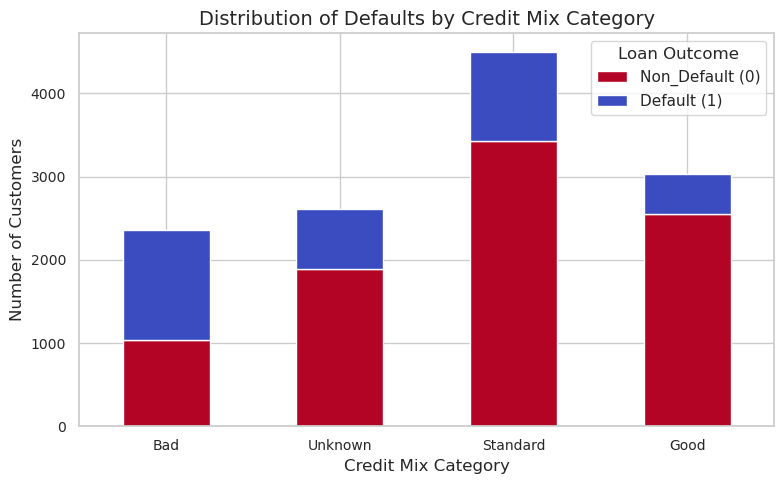

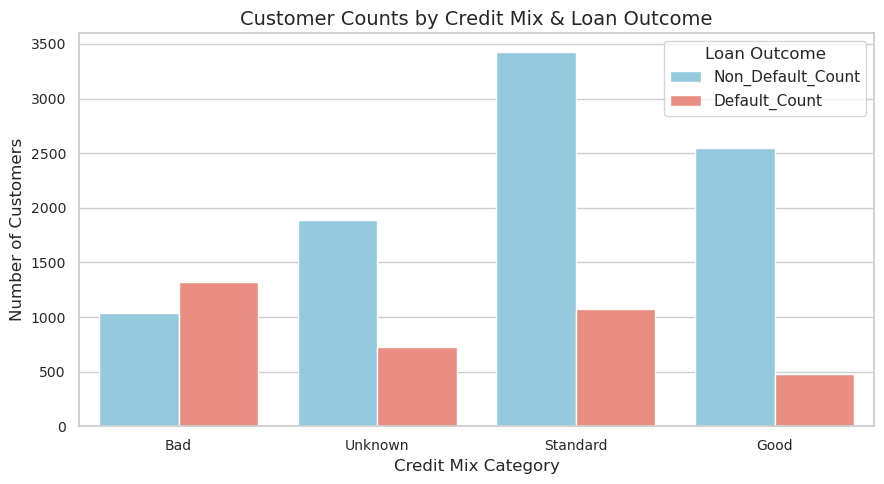

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data
data = {
    'Credit_Mix': ['Bad', 'Bad', 'Good', 'Good', 'Standard', 'Standard', 'Unknown', 'Unknown'],
    'label': [0, 1, 0, 1, 0, 1, 0, 1],
    'count': [1035, 1325, 2551, 481, 3426, 1071, 1886, 724]
}
df = pd.DataFrame(data)

# Calculate total counts and default rates per category
summary_list = []
for category in df['Credit_Mix'].unique():
    cat_df = df[df['Credit_Mix'] == category]
    count_0 = cat_df[cat_df['label'] == 0]['count'].sum()
    count_1 = cat_df[cat_df['label'] == 1]['count'].sum()
    total_count = count_0 + count_1
    default_rate = count_1 / total_count if total_count > 0 else 0
    summary_list.append({
        'Credit_Mix': category,
        'Non_Default_Count': count_0,
        'Default_Count': count_1,
        'Total_Count': total_count,
        'Default_Rate': default_rate
    })

summary_df = pd.DataFrame(summary_list)
summary_df = summary_df.sort_values('Default_Rate', ascending=False) # Sort for better visualization

print("Summary DataFrame for Plotting:")
print(summary_df)

# --- Plot 1: Bar Chart of Default Rates ---
plt.figure(figsize=(8, 5)) # Smaller size suitable for a slide
sns.set_theme(style="whitegrid")
barplot = sns.barplot(x='Credit_Mix', y='Default_Rate', data=summary_df, palette="viridis")

# Add percentages on top of bars
for index, row in summary_df.iterrows():
    barplot.text(index, row.Default_Rate + 0.01, # Adjust offset as needed
                 f"{row.Default_Rate*100:.1f}% (n={row.Total_Count})", 
                 color='black', ha="center", va="bottom", fontsize=9)

plt.title('Default Rate by Credit Mix Category', fontsize=14)
plt.xlabel('Credit Mix Category', fontsize=12)
plt.ylabel('Default Rate', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, summary_df['Default_Rate'].max() * 1.15 if not summary_df.empty else 1) # Adjust y-axis limit
plt.tight_layout()
plt.show()

# --- Plot 2: Stacked Bar Chart of Counts ---
# Pivot data for stacked bar chart
pivot_df = df.pivot(index='Credit_Mix', columns='label', values='count').fillna(0)
pivot_df.columns = ['Non_Default (0)', 'Default (1)']
pivot_df = pivot_df.reindex(summary_df['Credit_Mix']) # Order like the default rate plot

plt.figure(figsize=(8, 5))
pivot_df.plot(kind='bar', stacked=True, colormap='coolwarm_r', ax=plt.gca())

plt.title('Distribution of Defaults by Credit Mix Category', fontsize=14)
plt.xlabel('Credit Mix Category', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0, ha="center", fontsize=10) # Keep x-axis labels horizontal if possible
plt.yticks(fontsize=10)
plt.legend(title='Loan Outcome')
plt.tight_layout()
plt.show()

# --- Plot 3: Grouped Bar Chart of Counts (Alternative to Stacked) ---
plt.figure(figsize=(9, 5))
# We need to melt the summary_df to use with seaborn's hue
plot_df_melted = summary_df.melt(id_vars=['Credit_Mix', 'Total_Count', 'Default_Rate'], 
                                 value_vars=['Non_Default_Count', 'Default_Count'],
                                 var_name='Outcome_Type', value_name='Count')

grouped_barplot = sns.barplot(x='Credit_Mix', y='Count', hue='Outcome_Type', data=plot_df_melted, palette={'Non_Default_Count':'skyblue', 'Default_Count':'salmon'})

plt.title('Customer Counts by Credit Mix & Loan Outcome', fontsize=14)
plt.xlabel('Credit Mix Category', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0, ha="center", fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Loan Outcome')
plt.tight_layout()
plt.show()



*Visualize*

## Attributes feature

## Clickstream feature 

## Loans feature

## Loan labels 

In [11]:
from pyspark.sql.functions import col, when

#Load loans from silver
loans = spark.read.parquet("datamart/silver/loans_clean")

#Filter loans where mob == 6 and generate label
loans_label = loans.filter(col("mob") == 6)
loans_label = loans_label.withColumn("label", when(col("dpd") >= 30, 1).otherwise(0))

#Load cleaned financials
financials = spark.read.parquet("datamart/silver/financials_clean")

#Join financials with loans on Customer_ID and snapshot_date
financials_label = financials.join(loans_label.select("Customer_ID", "snapshot_date", "label"), 
                                   on=["Customer_ID", "snapshot_date"], how="inner")


financials_label.toPandas().to_csv("eda_outputs/financials_with_label.csv", index=False)

print("✅ Saved financials_with_label.csv")


✅ Saved financials_with_label.csv
